# Example for I_SFA066: South Fork of the American River Near Kyburz

This python notebook follows the general workflow of the upper_american_calculate_rim_inflows.py, but is paired back to only calucate flows for I_SFA066.

Steps for I_SFA066:
* Import input dataset used for the previous extension
* Gapfill datasets needed for unimpairment (Reservoir Evaporation at Caples, Silver, and Aloha Lakes)
* Unimpair flows for I_SFA066 by accounting for upstream reservoir storage changes, adding back reservoir evaporation, and subracting out the Echo Lake Conduit (Echo Lake flows are conveyed into the SF American via conveyance system), these flows are accounted for in I_ECHOL
* Extend the period of record using an s-curve disagg with FNF data for the American River at Folsom CDEC data
* Calculate Rim Inflows (fRim Inflow for SFA066 = Unimpaired flow for USGS 11439501 SF American 11439501 - I_CAPLS, I_SILVR, I_ALOHA, and I_PYR001 flows) ** Note we'll pull in previously calculated inflows for these upstream locations.

In [9]:

# Import needed packages and extenion, impairment, rim inflow, and evaporation functions

import os
print("current directory is ", os.getcwd())
os.chdir("/Users/jsaunders/code/calsim/cal-sim-rim-inflow-extension-saunders01")
print("current directory is ", os.getcwd())

from extension_functions import *
from unimpairment_functions import *
from rim_inflow_functions import *
from evaporation_functions import *
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

current directory is  C:\Users\jsaunders\code\calsim\cal-sim-rim-inflow-extension-saunders01
current directory is  C:\Users\jsaunders\code\calsim\cal-sim-rim-inflow-extension-saunders01


In [10]:
# Previous Spreadsheet file for French Meadows to compare results with
s_old_spreadsheet_fn = 'Examples/CS3_I_SFA066_Rev2022G.xlsm'

## Import Model Input Data
For this example we'll use the input dataset from the previous extension (through 2021) from the spreasheet. For rim watersheds in the Upper American, this data is included in the Inputs/Upper_american_2022_extension_data.csv.
Using these inputs will allows us to compare the python workflow results with the excel spreadsheet results.
i_final_year should be set to the end water year of the last extension (2021)

### To use an extended input dataset
You wil need to run upper_armerican_data_read.py to generate the updated model inputs. This script will develop an extended dataset saved here: /Intermediate/upper_american_full_gauge_data_wevap.csv that would then be imported in place of the previous extension dataset

In [11]:
i_final_year = 2021

# this holds the already extended evap rates
s_evap_dss_path = r".\Inputs\evaporation_rates.dss"

# option to plot comparison between python and excel workflows
b_compareData = True
s_prev_rim_inflows_fn = "Examples/CS3_Sac_ReadAllInflowDatatoDSS_05.18.23.xlsm" # file path and name must be provided to plot/calculate comparison
s_prev_rim_inflow_sheet = "Inflows"

# first if the needed output folders don't exist, create them
os.makedirs('./Intermediate', exist_ok=True)
os.makedirs('./Figures', exist_ok=True)
os.makedirs('./Outputs', exist_ok=True)

# read in the data that we already read in
df_full_data = pd.read_csv('./Inputs/upper_american_2022_extension_data.csv', index_col=0, parse_dates=True) # this will pull in the last extension dataset (through 2021) which matches the spreadsheets (w/ the exception of some minor corrected dataset errors)
df_full_data.replace(-901, np.nan, inplace=True) # set -901 to nan

# if using the extended dataset uncomment the line below
#df_full_data = pd.read_csv('./Intermediate/upper_american_full_gauge_data.csv', index_col=0, parse_dates=True) # this will read in the extended data set if you run upper_american_data_read.py


,11427400,11427500,11427700,11427750,11427200,AMF,11427760,11439501,11434900,11428000,...,Folsom Diversions,Folsom South Canal,Folsom,YB90,YB91,Folsom Fair Oaks,11443450,Folsom_evap,NAT_evap,11433930
1921-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.450,NaN,...,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1921-10-31,NaN,NaN,NaN,NaN,NaN,14.200,NaN,NaN,1.450,NaN,...,5.000000,0.000000,0.000,14.700000,NaN,0.070890,NaN,0.000,0.000000,0.000000
1921-11-30,NaN,NaN,NaN,NaN,NaN,38.800,NaN,NaN,0.000,NaN,...,5.000000,0.000000,0.000,14.900000,NaN,0.036033,NaN,0.000,0.000000,0.000000
1921-12-31,NaN,NaN,NaN,NaN,NaN,131.000,NaN,NaN,0.000,NaN,...,4.000000,0.000000,0.000,10.200000,NaN,3.070438,NaN,0.000,0.000000,0.000000
1922-01-31,NaN,NaN,NaN,NaN,NaN,112.700,NaN,NaN,0.000,NaN,...,4.000000,0.000000,0.000,9.500000,NaN,0.365099,NaN,0.000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-05-31,73.4,0.983802,2.318083,0.612417,0.099610,128.443,2.730050,25.492760,3.471,NaN,...,10.516364,1.047273,361.043,1.537190,NaN,0.059097,9.434,4.122,0.240000,1.074050
2021-06-30,71.3,0.660496,0.185058,0.164231,0.833058,32.390,1.303140,6.878678,4.051,NaN,...,11.038017,1.513388,288.402,1.491570,NaN,0.054029,8.849,4.388,0.285620,1.009587
2021-07-31,66.2,0.676364,0.034003,0.033572,2.502545,6.463,0.953058,4.310281,1.731,NaN,...,11.918678,1.676033,243.824,1.402314,NaN,0.057903,9.697,3.675,0.273719,0.902479
2021-08-31,58.5,0.657917,0.017401,0.017708,4.882116,0.000,0.873124,3.658512,0.930,NaN,...,10.754380,1.382479,233.573,1.120661,NaN,0.048427,8.802,2.836,0.232066,0.772760


## View Input Datasets
* 11435900 Silver Lake Storage
* 11436950 Caples Lake Storage
* 11434900 Lake Aloha Storage
* 11434500 Echo Lake Conduit
* 11435500 SF American R at Kyburz (TODO from JS Should this say "11439501 SF American" to match last entry of first line of code below?)
* CDEC FNF for the American River at Folsom Lake (AMF) covers the full period of record and will be used to extend the unimpaired flows

We'll plot the data to look at the available period of record

<Axes: >

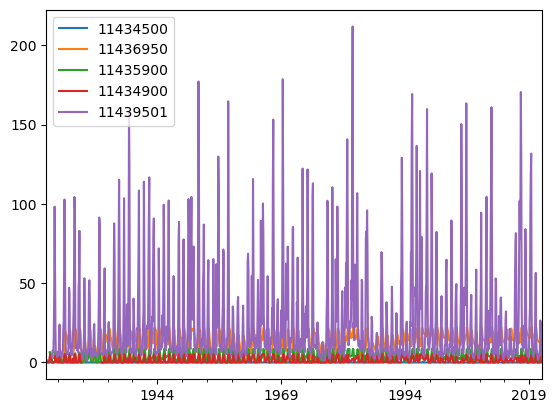

In [12]:
sl_usgs_stations = ['11434500','11436950','11435900','11434900','11439501']
sl_cdec_stations = ["AMF"]

# plot data for location
fig,ax = plt.subplots()
#df_full_data[sl_cdec_stations].plot(ax=ax)
df_full_data[sl_usgs_stations].plot(ax=ax)
#plt.ylim(0,60)

### Gapfill Datasets needed for unimpairment

Data is missing in a few of the USGS gage records, Gap fill the data sets as needed
A few different types of gapfilling are used in the spreadsheets. The main method is to fill in the data with average monthly values, this method is recreated in the 'gap_fill' function. For this location the missing datapoints in 1922 and 1923 are gapfilled with zeros in the original I_SFA066 spreadsheet, we'll utilize this method to compare with.

In [13]:

# gapfill caples storage a little different, these values were just set to zero
df_full_data.loc[(df_full_data['11436950'].isna()) & (df_full_data.index.year >= 1922) & (df_full_data.index.year <= 1924),'11436950'] = 0
df_full_data.loc[(df_full_data['11435900'].isna()) & (df_full_data.index.year >= 1922) & (df_full_data.index.year < 1923),'11435900'] = 0

gap_fill(df_full_data, { #'11436950': [1922, 1923, 1924],
                        '11435900': [1923], '11434900': list(range(1929, 1933))},
            i_final_year)


## Calculate Reservoir Evaporation Volumes, needed for unimpairment
Evaporation rates are calculated for Lake Aloha and Caples and Silver Lakes in the Reservoir Evaporation code. We'll import that data from the evap dss file and convert  it to volumes using reservoir storage information and area-capacity curves (included in the 'Area Capcities/' Folder). Each reservoir has it's own calc_evap function in 'evaporation_functions.py' tied to the gage number of the storage data.

In [14]:
calc_evap_11436950(s_evap_dss_path, df_full_data) # Caples lake 
calc_evap_11435900(s_evap_dss_path, df_full_data) # Silver Lake
calc_evap_11434900(s_evap_dss_path, df_full_data) # Lake Aloha


## Unimpair the gage data
Each unimpaired flow location has it's own function related to the gage number, 'unimpaired_11439501' in the 'unimpairment_functions.py'. To unimpair flow at this location we need to add storage changes for each of the three upstream reservoirs, add back evaporation from each reservoir and remove Echo Lake Conduit flows 

We'll also want to remove any negative flow values after the unimpairment. the 'remove_negatives_timeseries' function redistributes negative values proporitionally over other months in the water year to maintain the annual volume at the gage.

In [15]:
# Unimpair the data
df_unimpaired_data = pd.DataFrame()

df_unimpaired_data['11439501'] = unimpaired_11439501(df_full_data) 

# drop the first row which is only for calculating storage differences
df_unimpaired_data.drop(index=df_unimpaired_data.index[0], inplace=True)

# redistribute negatives - negatives are set to zero and the negative flows are redistributed to the rest of the wy propotionaly based on monthly flow, keeping the total annual flow the same
df_pos_unimpaired_data = remove_negatives_timeseries(df_unimpaired_data)

## Compare the unimpaired flows from the python workflow with the old excel spreadsheet to verify 
Unimpaired gage data is included in the I_SFA066 spreadsheet, on the 'Unimp SF American 11439501' sheet
We'll also go ahead and pull in other relevant datasets from the spreadsheet to compare into a single dataframe df_excel_all

Maximum Difference Between Datasets: 0.6854588828645181


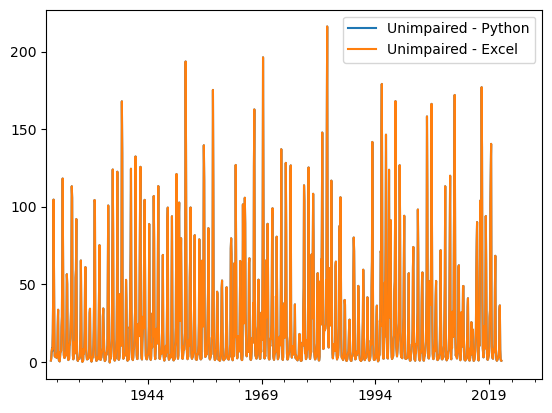

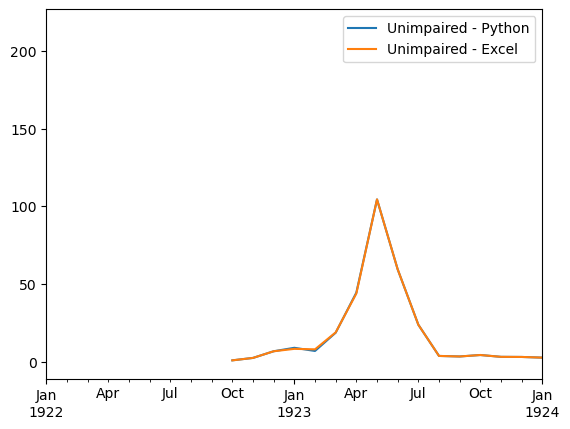

In [16]:
# grab all the same data from the excel sheet
# Import the data from the spreadsheets
l_column_names = ['CaplesEvap','SilverEvap','AlohaEvap','CaplesSto','SilverSto','AlohaSto','EchoConduit',\
                  'GageData','GageData_Unimp','GageData_Unimp_Pos_Extended','I_SFA066']
l_sheet = ['Caples Evaporation','Silver Evaporation','Aloha Evaporation','Extended Caples Storage','Extended Silver Storage','Aloha Storage Infilled','Echo Lake Conduit 11434500',\
           'SF American 11439501','Unimp SF American 11439501','MODELA','SV INPUT']
l_usecols = ['B:D'] * (len(l_sheet)-2) + ['AF:AG'] + ['A:D']
l_fn = [s_old_spreadsheet_fn] * len(l_sheet)
l_skiprows = [14] * (len(l_sheet)-2) + [7] + [17]

l_spreadsheet_dfs = []
for s_colname,s_sheet,s_usecols,s_fn,i_skiprows in zip(l_column_names,l_sheet,l_usecols,l_fn,l_skiprows):

    # read the data from the spreadsheet
    df_excel_spreadsheet = pd.read_excel(s_fn,
                                    sheet_name = s_sheet,
                                    skiprows= i_skiprows,
                                    usecols=s_usecols,
                                    index_col=0)
    
    if s_colname[-3:] == 'Sto': # storage sheets are a little different
        df_excel_spreadsheet.columns = ['cfs','TAF']
    if s_colname[:2] == 'I_': # inflow location
        df_excel_spreadsheet.columns = ['year','month','TAF']
    df_excel_spreadsheet.loc[df_excel_spreadsheet['TAF']==-901,'TAF'] = np.nan # remove -901 values
    l_spreadsheet_dfs.append(df_excel_spreadsheet['TAF'])

df_excel_all = pd.concat(l_spreadsheet_dfs,axis=1,sort=True)
df_excel_all.columns = l_column_names

# calculate storage changes
for s_sto in ['CaplesSto','SilverSto','AlohaSto']:
    df_excel_all[s_sto + 'Chng'] = df_excel_all[s_sto] - df_excel_all[s_sto].shift(1)

# If you want to double check that the equation we're using for unimpairment in the spreadsheet matches the fomula in the sheet we can recalculate (this is a good way to explore the unimpairment equation before creating the function for a new location) 
#df_excel_all['GageData_Unimp_check'] = df_excel_all['GageData'] + df_excel_all['CaplesStoChng']+ df_excel_all['SilverStoChng']+ df_excel_all['AlohaStoChng'] \
#    + df_excel_all['CaplesEvap']+ df_excel_all['SilverEvap']+ df_excel_all['AlohaEvap'] \
#    - df_excel_all['EchoConduit']
#df_excel_all['Diff'] =df_excel_all['GageData_Unimp_check'] - df_excel_all['GageData_Unimp']
#df_excel_all['Diff'].plot()

df_combined_unimpaired = pd.concat([df_unimpaired_data,df_excel_all['GageData_Unimp']], axis=1,sort=True)
df_combined_unimpaired['diff'] = df_combined_unimpaired['11439501'] - df_combined_unimpaired['GageData_Unimp']

df_combined_unimpaired[['11439501','GageData_Unimp']].plot()
plt.legend(labels=['Unimpaired - Python', 'Unimpaired - Excel'])
plt.plot()

date_max_error =df_combined_unimpaired[df_combined_unimpaired['diff'] == df_combined_unimpaired['diff'].max()].index[0]
df_combined_unimpaired[['11439501','GageData_Unimp']].plot()
plt.legend(labels=['Unimpaired - Python', 'Unimpaired - Excel'])
plt.xlim(date_max_error - pd.DateOffset(years=1),date_max_error + pd.DateOffset(years=1))
plt.plot()

print(f'Maximum Difference Between Datasets: {df_combined_unimpaired['diff'].max()}'  )


The unimpaired flows are vitually the same except for one date in 1923. This is due to a gapfilling difference in one of the datasets used for the unimpairment. These data are used in multiple inflows spreadsheets and were gapfilled differently. In the new python workflow, only one of the gapfilled dataset was kept to maintain consistency across the calculations. Because of this, very small isolated differences may occur between the python and excel workflows. 

## Extend the Dataset
Use data from FNF on the American River from CDEC (Station AMF). We'll use the unimpaired data from 1923 to 2021 to do the s-curve dissag w/ the AMF data. 

In [17]:
# Extend Dataset

# create dataframe for extension
df_extended_data = pd.DataFrame()
df_synthetic_data = pd.DataFrame()

# extend all with the s-curve disaggregation
extend_data(df_full_data['AMF'], df_pos_unimpaired_data['11439501'], df_extended_data, df_synthetic_data, 1923, i_final_year, False, '11439501', i_final_year=i_final_year)

### Compare Extended dataset with spreadsheet

Maximum Difference Between Datasets: 0.6854588828645181
Average Difference Between the Datasets: -8.061447626970502e-06
Maximum Difference Between Datasets after 1924: 0.013100018454186735


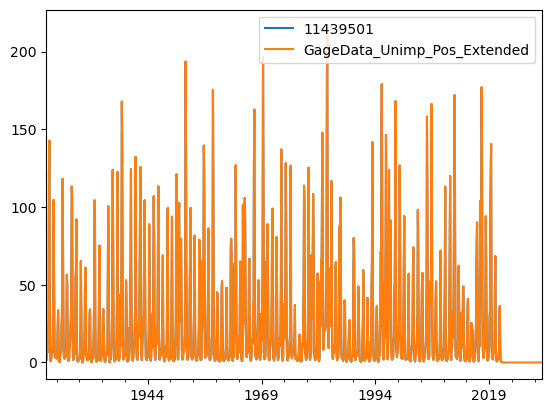

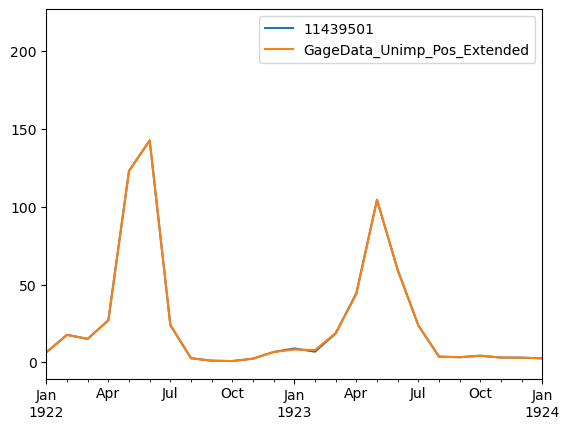

In [18]:

df_combined_extended = pd.concat([df_extended_data,df_excel_all['GageData_Unimp_Pos_Extended']], axis=1,sort=True)
df_combined_extended['diff'] = df_combined_extended['11439501'] - df_combined_extended['GageData_Unimp_Pos_Extended']

df_combined_extended[['11439501','GageData_Unimp_Pos_Extended']].plot()
plt.plot()

date_max_error =df_combined_extended[df_combined_extended['diff'] == df_combined_extended['diff'].max()].index[0]
df_combined_extended[['11439501','GageData_Unimp_Pos_Extended']].plot()
plt.xlim(date_max_error - pd.DateOffset(years=1),date_max_error + pd.DateOffset(years=1))
plt.plot()

print(f'Maximum Difference Between Datasets: {df_combined_extended['diff'].max()}'  )
print(f'Average Difference Between the Datasets: {df_combined_extended['diff'].mean()}')
print(f'Maximum Difference Between Datasets after 1924: {df_combined_extended.loc[df_combined_extended.index > '1924-01-01']['diff'].max()}'  )

There is little difference between the python calculated inflows and the spreadsheets values, except for that same 1923 data point as the unimpairment.

## Calculate Rim Inflows
The python code calls a location specific Rim Inflow function (here tied to the Inflow location abbreviation I_SFA066), included in rim_inflow_functions.py  
For this location, the inflow timeseries is set to the the extended unimpaired flows minus upstream inflows (I_CAPLS, I_SILVR, I_ALOHA, and I_PYR001) rounded to two decimal places. 

We'll need to use previously calculated I_CAPLS, I_SILVR, I_ALOHA, and I_PYR001 inflows to calculate these. To get this data, run the full upper_american_calculate_rim_inflows.py script and import the final output data from that run

In [20]:
# Calculate Rim Inflows 
# Rim inflows for SFA066 are equal to the unimpared gage data, minus upstream inflows

# these inflows were calculated in the full calculate_rim_inflows.py sheet
# For this example, example we'll pull in previous rim inflow data from the Ouptut folder
df_prev_rim_inflows = pd.read_csv('Outputs/upper_american_rim_inflows.csv',index_col=0)

df_rim_inflows = df_prev_rim_inflows[['I_CAPLS','I_SILVR','I_ALOHA','I_PYR001']].copy()
df_rim_inflows.index = pd.to_datetime(df_rim_inflows.index)

# calculate rim inflows for this location, it will add it to the df_rim_inflows dataframe
I_SFA066(df_extended_data, df_rim_inflows)

## Compare the python generated I_RCK001 Rim Inflow w/ the Previous Spreadsheet Dataset

In [21]:
# Compare with Previous Data
df_reference = pd.read_excel(s_prev_rim_inflows_fn, sheet_name=s_prev_rim_inflow_sheet, skiprows=[0,2,3,4,5,6,7,8,9,10,11],header=0, index_col=0, parse_dates=True)
df_diffs = abs(df_reference[df_rim_inflows.columns] - df_rim_inflows).max().to_frame('Max Difference')
df_diffs['Median Value - Original'] = df_reference[df_rim_inflows.columns].mean()
df_diffs['Median Value - Extension'] = df_rim_inflows.mean()

df_diffs['Max Percent Difference'] = (abs(df_reference[df_rim_inflows.columns] - df_rim_inflows)).max() / df_reference[df_rim_inflows.columns].mean()*100
df_diffs['Avg Percent Difference'] = (abs(df_reference[df_rim_inflows.columns] - df_rim_inflows)).mean() / df_reference[df_rim_inflows.columns].mean()*100
print("Maximum differences:")
print(df_diffs.sort_values(by='Max Difference', ascending=False).to_string())

Maximum differences:
          Max Difference  Median Value - Original  Median Value - Extension  Max Percent Difference  Avg Percent Difference
I_CAPLS            10.56                 2.430550                  2.431333              434.469565                1.584004
I_SFA066            3.88                 7.941783                  7.948075               48.855526                0.168833
I_PYR001            1.53                 1.622442                  1.622475               94.302312                0.292769
I_SILVR             1.03                 2.444917                  2.445067               42.128225                0.087256
I_ALOHA             0.95                 1.012250                  1.012275               93.850333                0.287314


Differnces between the python rim inflows and excel spreadsheet rim inflows accumulate as you move downstream. Changes in inflows at upstream locations, I_CAPLS, I_SILVR, I_PYR001, and I_ALOHA impact I_SFA066. Review accompanying documentation on why these upstream locations are different. For example I_CAPLS has some signficant differences due to variations in data gapfilling.

However, despite some larger differences, the overall differences between the datasets is minimal, and with the exception of caples, less than 0.1 percent.

### Additional Notes - Deep Dive
When exploring a new rim inflow, it can be useful to compare all the input datasets and when/where the max differences occur which could be impacting your unimpaired or extended flow datasets. See an example below.

Maximum difference for CaplesEvap is 3.458777969589377e-08 on 1963-08-31 00:00:00, with a % difference of 7.752586323082655e-06
Maximum difference for SilverEvap is 0.0025629992798120796 on 1923-03-31 00:00:00, with a % difference of 5.7366824901650215
Maximum difference for AlohaEvap is 0.001261064917935574 on 1929-10-31 00:00:00, with a % difference of 2.806094437146344
Maximum difference for CaplesSto is 0.0 on 1922-01-31 00:00:00, with a % difference of nan
Maximum difference for SilverSto is 0.6850959595959596 on 1923-01-31 00:00:00, with a % difference of 87.55219930938782
Maximum difference for AlohaSto is 0.011455433848797214 on 1929-09-30 00:00:00, with a % difference of 3.3809501321503137
Maximum difference for CaplesStoChng is 0.0 on 1922-02-28 00:00:00, with a % difference of nan
Maximum difference for SilverStoChng is 1.0631199494949495 on 1923-02-28 00:00:00, with a % difference of 87.45459738775935
Maximum difference for AlohaStoChng is 0.011455433848797242 on 1929-10-31

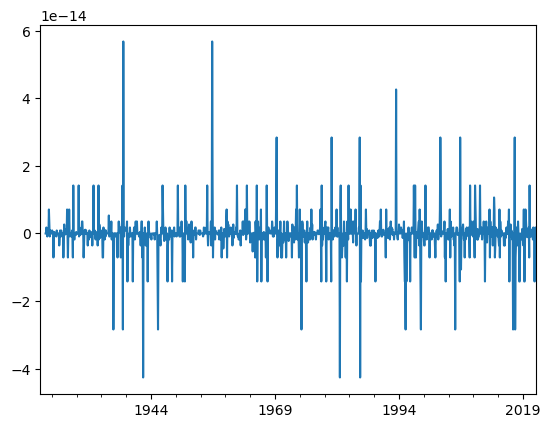

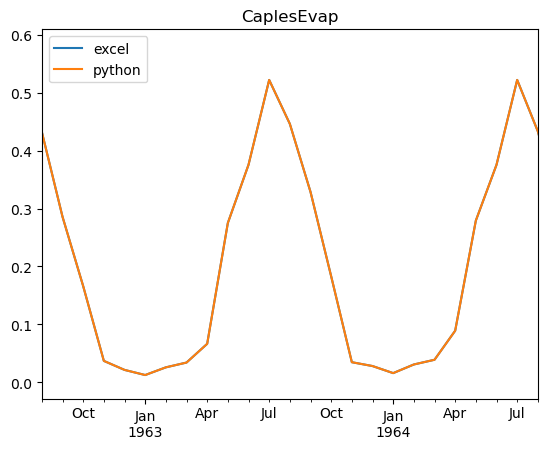

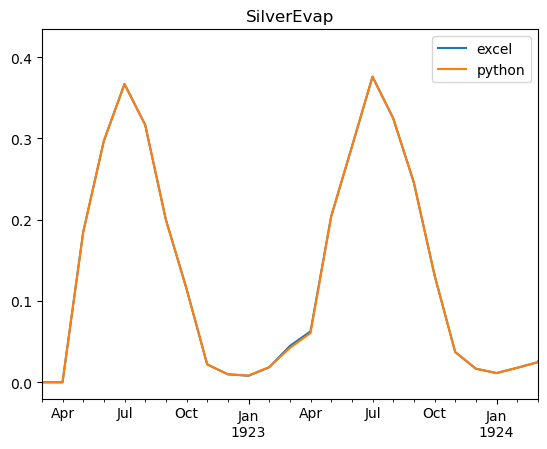

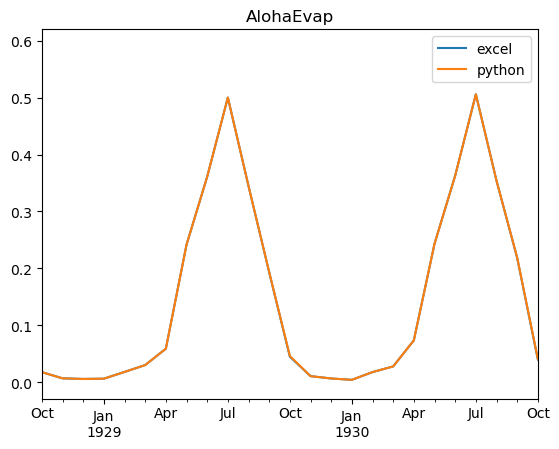

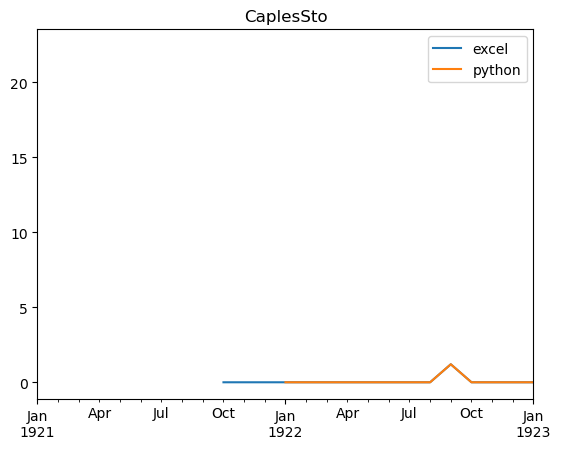

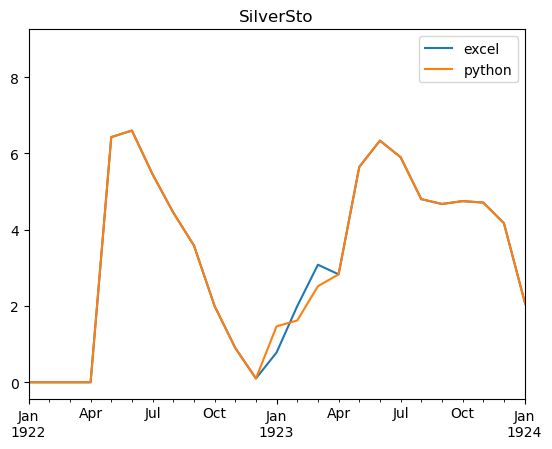

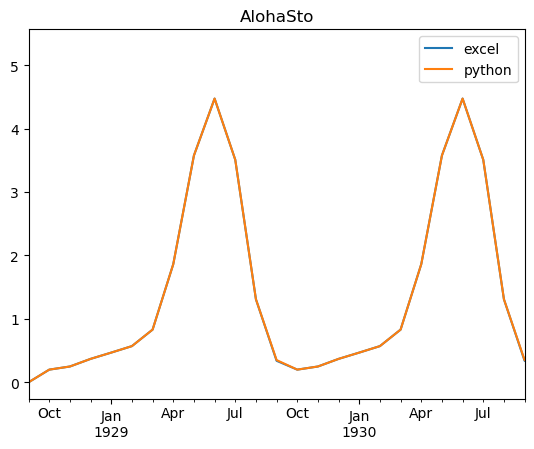

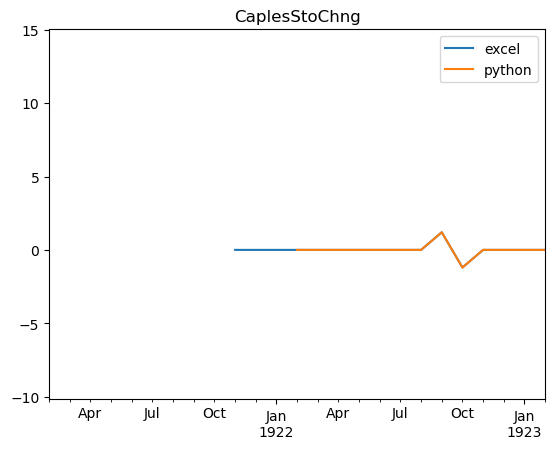

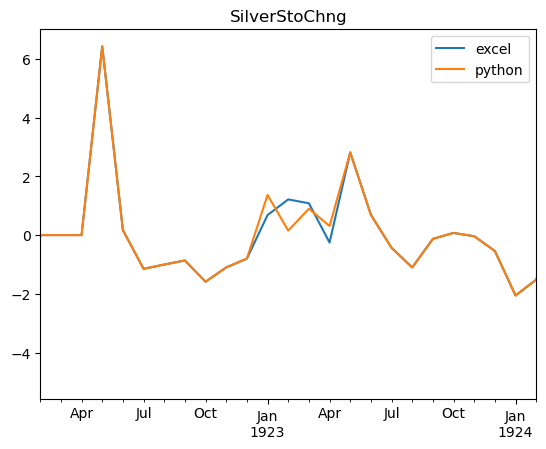

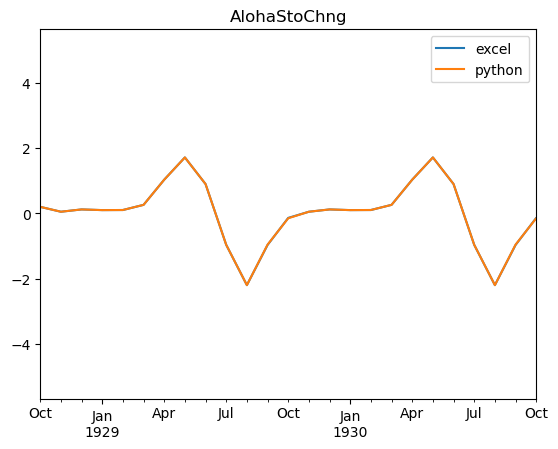

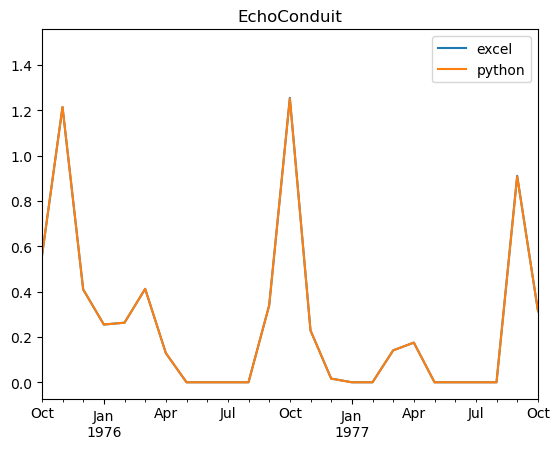

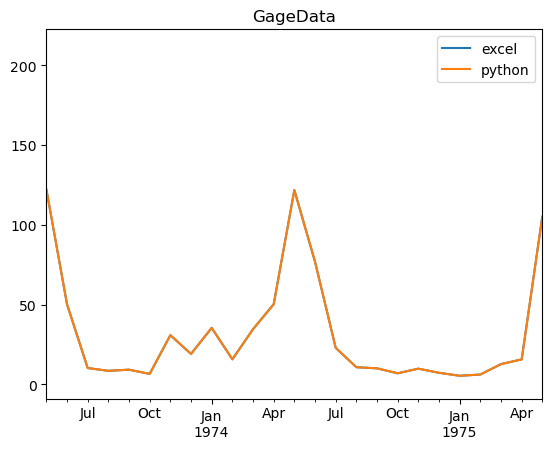

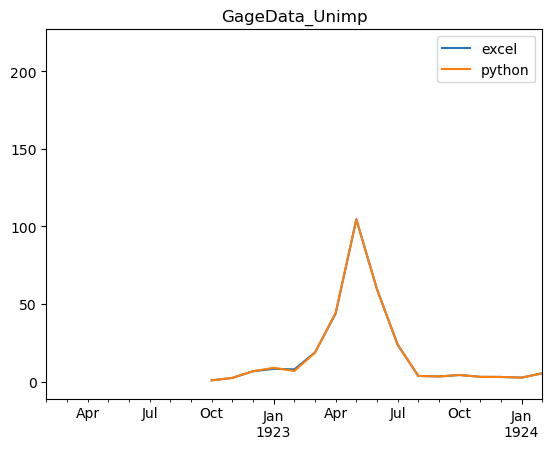

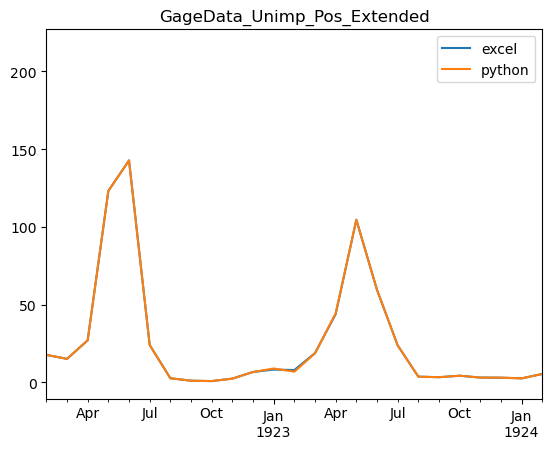

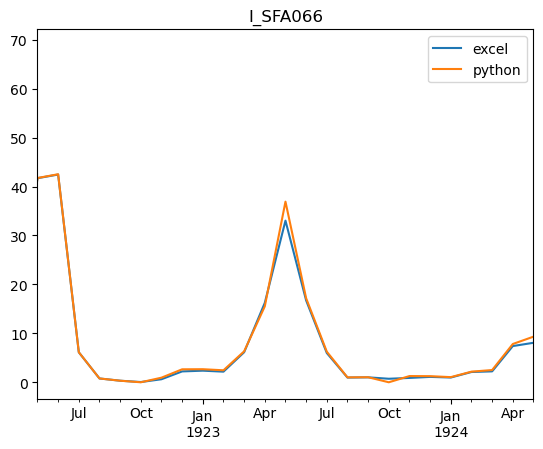

In [22]:

# Deep Dive on all the variables in the calculation to look at maximum differences

# First pull all python variables used for the unimpairment and extension to compare 

l_variables = []

# gage data
l_variables.append(df_full_data[['11439501','11436950','11435900','11434900']])

# grab storages & Calculate change
l_variables.append(df_full_data['11436950'] - df_full_data['11436950'].shift(1)) # Caples Lake
l_variables.append(df_full_data['11435900'] - df_full_data['11435900'].shift(1)) # Silver Lake
l_variables.append(df_full_data['11434900'] - df_full_data['11434900'].shift(1)) # Silver Lake

# grab evaporation
l_variables.append(df_full_data['11436950_evap']) # Caples Lake Evap
l_variables.append(df_full_data['11435900_evap']) # Silver Lake Evap
l_variables.append(df_full_data['11434900_evap']) # Aloha Evap

# echo conduit
l_variables.append(df_full_data['11434500']) # Echo conduit

# Unimpaired Data
l_variables.append(df_unimpaired_data['11439501']) #SF AMERICAN R NR KYBURZ TOTAL FLOW CA
# l_variables.append(df_full_data['AMF']) # data used for the extension, full natural flows on the american MF from CDEC

# extended data
l_variables.append(df_extended_data['11439501'])

# final rim inflow
l_variables.append(df_rim_inflows['I_SFA066'])


df_all_python_data = pd.concat(l_variables,axis=1)
df_all_python_data.columns = ['GageData','CaplesSto','SilverSto','AlohaSto','CaplesStoChng','SilverStoChng','AlohaStoChng',\
                             'CaplesEvap','SilverEvap','AlohaEvap','EchoConduit',\
                                'GageData_Unimp','GageData_Unimp_Pos_Extended','I_SFA066']

df_all_python_data['GageData_Unimp_check'] = df_all_python_data['GageData'] + df_all_python_data['CaplesStoChng']+ df_all_python_data['SilverStoChng']+ df_all_python_data['AlohaStoChng'] \
    + df_all_python_data['CaplesEvap']+ df_all_python_data['SilverEvap']+ df_all_python_data['AlohaEvap'] \
    - df_all_python_data['EchoConduit'] # this same calculation is included in the unimpairment function 'unimpaired_11439501'

# double check unimpairment function matches as expected, there should be no difference (or small rounding differences)
df_all_python_data['Diff'] = df_all_python_data['GageData_Unimp_check'] - df_all_python_data['GageData_Unimp']
df_all_python_data['Diff'].plot()


# Loop through all variables and plot a comparison
l_plt_vars =  ['CaplesEvap','SilverEvap','AlohaEvap','CaplesSto','SilverSto','AlohaSto',\
               'CaplesStoChng','SilverStoChng','AlohaStoChng','EchoConduit',\
                'GageData','GageData_Unimp','GageData_Unimp_Pos_Extended','I_SFA066']

for s_plt_var in l_plt_vars:

    df_compare = pd.concat([df_all_python_data[s_plt_var],df_excel_all[s_plt_var]],axis=1)
    df_compare.columns = ['python','excel']
    df_compare['diff'] = abs(df_compare['python'] - df_compare['excel'])
    df_compare['perDiff'] = df_compare['diff'] / df_compare['excel'] * 100


    date_max_error = df_compare[df_compare['diff'] == df_compare['diff'].max()].index[0]

    print(f'Maximum difference for {s_plt_var} is {df_compare['diff'].max()} on {date_max_error}, with a % difference of {df_compare['perDiff'].loc[date_max_error]}')

    #fig,ax = plt.subplots()
    df_compare[['excel','python']].plot()
    plt.title(s_plt_var)
    plt.xlim(date_max_error - pd.DateOffset(years=1),date_max_error + pd.DateOffset(years=1))
    plt.plot()